In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchsummary import summary
import numpy as np
import matplotlib.pyplot as plt

### Loading Data

In [ ]:
training_data = datasets.mnist.FashionMNIST(root="data", train=True, download=True, transform=ToTensor())
test_data = datasets.mnist.FashionMNIST(root="data", train=False, download=True, transform=ToTensor())

100%|██████████| 26.4M/26.4M [00:03<00:00, 7.29MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 154kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.3MB/s]


In [ ]:
training_data, validation_data = torch.utils.data.random_split(training_data, [50000, 10000])

In [ ]:
print(len(training_data),len(validation_data),len(test_data))

50000 10000 10000


### Fixed MLP with Increasing Training Dataset

Create a MLP with one hidden layer with 200 units for Fashion MNIST classification. Use ReLU activation.

Use a random fraction of the training set (split above) to perform the training. Always use the same validation set.

Use SGD and cross-entropy loss and suitable learning rate.

Start with a single small batch for training (batch size 8) and make sure that you can overfit, i.e. bring the training accuracy to 100%.

Then, gradually increase the training set. Let it grow until you obtain values for the training and the validation loss which no longer indicate overfitting. Use a fixed batch size (batchsize 32).

#### MLP Class

In [ ]:
# define a method that provides an instance of an MLP which uses as a list of units per layer as input

def mlp(units = [28*28, 200, 10]):
    """
    Creates an instance of an MLP with layers as specified in the 'units'-list (list of integers).
    input(flatten) -> hidden(linear) -> ReLU -> output(linear)
    inputs : 28*28 units
    hidden : 200 units
    output : 10 units (for the 10 possible labels)
    """
    # YOUR CODE HERE #
    couches = []
    couches.append(torch.nn.Flatten())   # flatten la matrice d'image en vect
    for i in range(len(units)-1):       # relier chaque couche à la suivante
        couches.append(torch.nn.Linear(units[i], units[i+1]))

        if i < len(units) - 2 :     # ReLU après chaque couche cachée (sauf la dernière)
          couches.append(torch.nn.ReLU())

    return torch.nn.Sequential(*couches)

In [ ]:
# create an instance and its summary

model = mlp()
from torchsummary import summary
summary(model, (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 200]         157,000
              ReLU-3                  [-1, 200]               0
            Linear-4                   [-1, 10]           2,010
Total params: 159,010
Trainable params: 159,010
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.61
Estimated Total Size (MB): 0.62
----------------------------------------------------------------


#### Training Loop

In [ ]:
from re import M
def train_eval(model, lr, nepochs, nbatch, training_data, validation_data):
    """
    Performs the training of a model with given learning rate (lr),
    number of epochs (nepochs), batchsize (nbatch) and training and validation data.
    Suitable data loaders are instantiated for the training and validation datasets.
    Keep book about cost and accuracy (per epoch) for both training and validation set.
    """
    cost_hist = []
    cost_hist_test = []
    acc_hist = []
    acc_hist_test = []

    # YOUR CODE HERE #

    # Data loaders
    training_data_loader = DataLoader(training_data, batch_size = nbatch, shuffle = True)
    validation_data_loader = DataLoader(validation_data, batch_size = nbatch, shuffle = True)

    # Optimizer : SGD
    optimizer = torch.optim.SGD(model.parameters(), lr = lr)

    # Fonction de cost : cross entropie
    cost_function = torch.nn.CrossEntropyLoss()

    # training
    for epoch in range(nepochs):
      model.train()
      cost = 0.0
      correct = 0
      total = 0
      acc = 0.0
      for X, Y in training_data_loader:
        # forward
        Y_pred = model(X)
        loss = cost_function(Y_pred, Y)
        cost += loss.item()

        # backward
        optimizer.zero_grad()
        ## 1. calcul du gradient
        loss.backward()
        ## 2. mise à jour des paramètres de l'optimizer
        optimizer.step()

        correct += (Y_pred.argmax(dim=1) == Y).sum().item()
        total += len(Y)

      cost /= len(training_data_loader)
      acc = correct / total

      cost_hist.append(cost)
      acc_hist.append(acc)

      # validation
      model.eval()
      cost_test = 0.0
      correct_test = 0
      total_test = 0
      acc_test = 0.0
      with torch.no_grad():
        for X_test, Y_test in validation_data_loader:
          Y_pred_test = model(X_test)
          loss_test = cost_function(Y_pred_test, Y_test)
          cost_test += loss_test.item()

          correct_test += (Y_pred_test.argmax(dim=1) == Y_test).sum().item()
          total_test += len(Y_test)

        cost_test /= len(validation_data_loader)
        acc_test = correct_test / total_test

        cost_hist_test.append(cost_test)
        acc_hist_test.append(acc_test)

    return cost_hist, cost_hist_test, acc_hist, acc_hist_test

#### First Training

Run a first training with only one small training batch (e.g. with a single batch of 64 samples).
The small training set can be created by using the functionality `torch.utils.data.random_split` already used above. As validation set use the `validation_data` created above.  

This training run can be used to test whether the model and training loop are properly implemented. Explain why and in what sense it can be used as test.

This is something you can always do when training a model.

32 49968


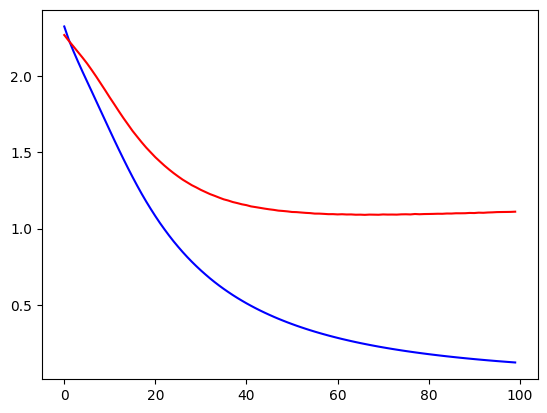

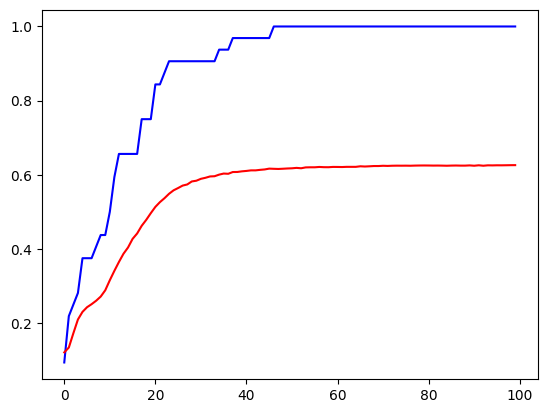

In [ ]:
# a single batch de 32 samples
nbatch = 32
nbatches = 1
nepochs = 100
lr = 0.1

trainsize = nbatches*nbatch
trainset, rest = torch.utils.data.random_split(training_data, [trainsize, 50000-trainsize])
print(len(trainset), len(rest))

model = mlp([28*28, 200, 10])
cost_train, cost_valid, acc_train, acc_valid = train_eval(model, lr, nepochs, nbatch, trainset, validation_data)

plt.figure(1)
plt.plot(range(nepochs), cost_train, "b-")
plt.plot(range(nepochs), cost_valid, "r-")

plt.figure(2)
plt.plot(range(nepochs), acc_train, "b-")
plt.plot(range(nepochs), acc_valid, "r-")

*La précision pour le train a été amené à 100%. Nous pouvons donc observer de l'overfitting.*    

*Le modèle a appris par coeurs les règles de classification, et produit donc de mauvais résultats pour le test avec une précision de ~60%.*

*La précision étant maximale pour le train, nous pouvons conclure que le model et la training loop ont été bien implémentés. En effet, sur un tout petit dataset de train (seulement un batch de 32 images), les règles de classification ont été facilement apprises (ce qui a mené à de l'overfitting). Cela nous permer d'affirmer que l'apprentissage c'est bien passé.*

*Toutefois, les paramètres nbatch, nepochs et lr doivent être corrigés pour obtenir de meilleurs performances sur le train.*



#### Evaluate Train and Validation Performance

Now run several trainings with the same small model (one hidden layer) and explore for different number of training samples (different number of batches with 32 samples) used, how the train and validation performance evolve (cost and accuracy). Make sure that you train sufficiently long to obtain representative values for cost and accuracy with the given settings. Always use the same validation set (with 10'000 samples).


In [ ]:
print(len(validation_data))

10000


In [ ]:
lr = 0.1
nepochs = 100
nbatch = 32

In [ ]:
# 1. nbatches = 10        /!\ running time : 3min
nbatches = 10
model = mlp([28*28, 200, 10])
trainsize = nbatches*nbatch
trainset = torch.utils.data.random_split(training_data, [trainsize, 50000-trainsize])[0]
cost_train1, cost_valid1, acc_train1, acc_valid1 = train_eval(model, lr, nepochs, nbatch, trainset, validation_data)

In [ ]:
# 2. nbatches = 50        /!\ running time : 3min
nbatches = 50
model = mlp([28*28, 200, 10])
trainsize = nbatches*nbatch
trainset = torch.utils.data.random_split(training_data, [trainsize, 50000-trainsize])[0]
cost_train2, cost_valid2, acc_train2, acc_valid2 = train_eval(model, lr, nepochs, nbatch, trainset, validation_data)

In [ ]:
# 3. nbatches = 100         /!\ running time : 4min
nbatches = 100
model = mlp([28*28, 200, 10])
trainsize = nbatches*nbatch
trainset = torch.utils.data.random_split(training_data, [trainsize, 50000-trainsize])[0]
cost_train3, cost_valid3, acc_train3, acc_valid3 = train_eval(model, lr, nepochs, nbatch, trainset, validation_data)

In [ ]:
# 4. nbatches = 500       /!\ running time : 6min
nbatches = 500
model = mlp([28*28, 200, 10])
trainsize = nbatches*nbatch
trainset = torch.utils.data.random_split(training_data, [trainsize, 50000-trainsize])[0]
cost_train4, cost_valid4, acc_train4, acc_valid4 = train_eval(model, lr, nepochs, nbatch, trainset, validation_data)

In [ ]:
# 5. nbatches = 1000       /!\ running time : 12min
nbatches = 1000
model = mlp([28*28, 200, 10])
trainsize = nbatches*nbatch
trainset = torch.utils.data.random_split(training_data, [trainsize, 50000-trainsize])[0]
cost_train5, cost_valid5, acc_train5, acc_valid5 = train_eval(model, lr, nepochs, nbatch, trainset, validation_data)


Create plots with training and validation performance vs number of training batches (one for cost and one for accuracy). Use the performance characteristics obtained at the end.


### *COST*

<function matplotlib.pyplot.show(close=None, block=None)>

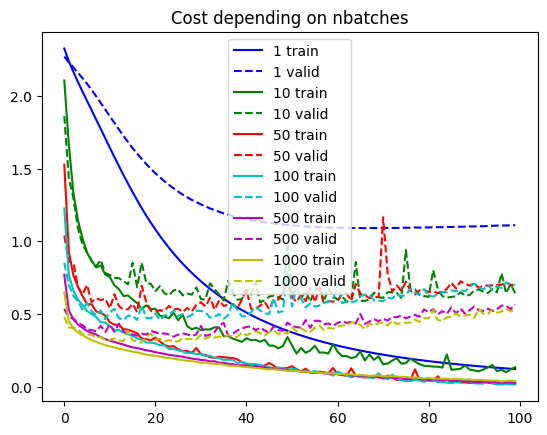

In [ ]:
legend = ["1 train", "1 valid", "10 train", "10 valid", "50 train", "50 valid", "100 train", "100 valid", "500 train", "500 valid", "1000 train", "1000 valid"]
ycost_train = [cost_train, cost_train1, cost_train2, cost_train3, cost_train4, cost_train5]
ycost_valid = [cost_valid, cost_valid1, cost_valid2, cost_valid3, cost_valid4, cost_valid5]
yacc_train = [acc_train, acc_train1, acc_train2, acc_train3, acc_train4, acc_train5]
yacc_valid = [acc_valid, acc_valid1, acc_valid2, acc_valid3, acc_valid4, acc_valid5]
plt.figure(1)
co= ['b', 'g', 'r', 'c', 'm', 'y']
for i in range(6):
  plt.plot(range(nepochs), ycost_train[i], linestyle = '-',c=co[i])
  plt.plot(range(nepochs), ycost_valid[i], linestyle = '--',c=co[i])


plt.legend(legend)
plt.title("Cost depending on nbatches")
plt.show

### *ACCURACY*

<function matplotlib.pyplot.show(close=None, block=None)>

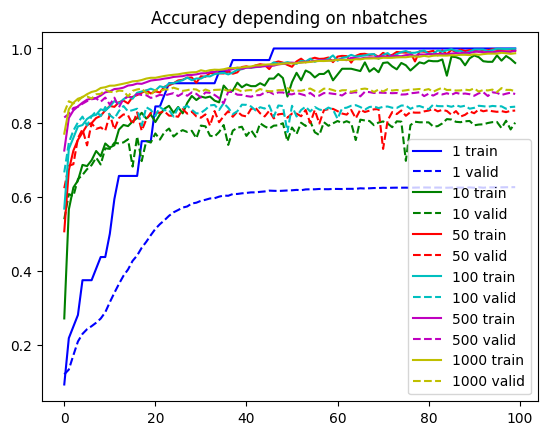

In [ ]:
for i in range(6):
  plt.plot(range(nepochs), yacc_train[i], linestyle = '-',c=co[i])
  plt.plot(range(nepochs), yacc_valid[i], linestyle = '--',c=co[i])


plt.legend(legend)
plt.title("Accuracy depending on nbatches")
plt.show


Discuss the whether there is a sufficient number of training samples for the given problem at hand. Specify a minimum number if applicable. Also consider whether you are in the underfitting regime.

*Le set d'entraînement est très petit par rapport à la validité, c'est pourquoi la cost de la validité est toujours au dessus de celle du test. Mais nous pouvons voir que plus nous augmentons le nbatches, plus la différence entre l'acc_train et l'acc_valide rétrécit, donc au plus on a des nbatches au moins on encontre le phénomène d'overfitting. La courbe pointillé (sur la validation) se rapproche peu à peu de la courbe continue (sur le train).*

*Cependant, au lieu d'augmenter nbatches, nous pouvons revoir la taille du set de training (50 000). Il est ici trop grand par rapport aux sets de test (10 000) et de validation (10 000). Il est usuel de dédier 80% d'un dataset à l'entrainement, 10% au test et 10% à la validation. Cela permet au modèle de s'entrainement sur plus de données et d'apprendre à mieux généraliser.*

*Nous devrions donc dédier 7 000 échantillons (10%)  à la validation, 7 000 échantillons (10%) au test et 56 000 échantillons (80%) à l'entrainement. Nous pouvons donc conclure que la répartition usuelle du dataset Fashion MNIST n'a pas été respectée dès le début.*


*Une autre solution est d'ajouter de la régularisation, comme du dropout, pour améliorer les performances du modèles.*

### Evaluate Different Model Complexities

Use the same functionality implemented above (create MLP model, train and evaluate model) to evaluate different model complexities: Number of layers and number of units per layer.

Start with the small model used in Exercise 2. Then gradually increase the model complexity. Do this along two dimensions:
* a single hidden layer, but **increasing the number of units.**
* a fixed number of units per (hidden) layer, but i**ncrease the number of layers.**
Make sure that you reach the overfitting regime (in either case).

Always use the full training set with 50'000 samples.

Again make sure that you train sufficiently long so that the obtained train and validation performance measures (cost, accuracy) are representative.

Create plots with training and validation performance (cost, accuracy) vs model complexity - one plot with number of units for the single hidden layer case, and one for varying number of layers.

Again use the performance characteristics obtained at the end.

Finally, discuss your findings.

In [ ]:
nbatch = 64
nepochs = 50
lr = 0.1

In [ ]:
# 1. One hidden layer with 200 units
model_1 = mlp([28*28, 200, 10])
cost_train_1, cost_valid_1, acc_train_1, acc_valid_1 = train_eval(model_1, lr, nepochs, nbatch, training_data, validation_data)

In [ ]:
# 2. One hidden layer with 500 units
model_2 = mlp([28*28, 500, 10])
cost_train_2, cost_valid_2, acc_train_2, acc_valid_2 = train_eval(model_2, lr, nepochs, nbatch, training_data, validation_data)

In [ ]:
# 3. One hidden layer with 100 units
model_3 = mlp([28*28, 100, 10])
cost_train_3, cost_valid_3, acc_train_3, acc_valid_3 = train_eval(model_3, lr, nepochs, nbatch, training_data, validation_data)

In [ ]:
# 4. One hidden layer with 50 units
model_4 = mlp([28*28, 50, 10])
cost_train_4, cost_valid_4, acc_train_4, acc_valid_4 = train_eval(model_4, lr, nepochs, nbatch, training_data, validation_data)

### *COST*

<function matplotlib.pyplot.show(close=None, block=None)>

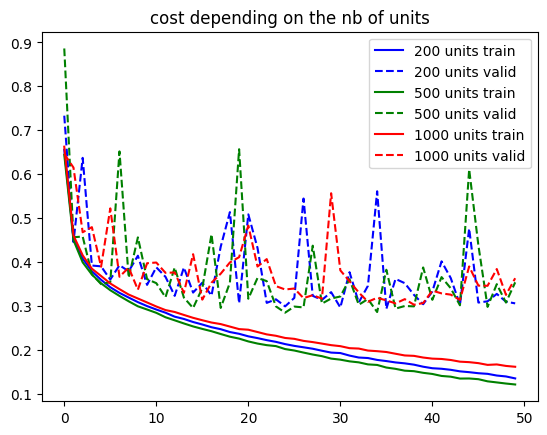

In [ ]:
legend = ["200 units train", "200 units valid", "500 units train", "500 units valid", "1000 units train", "1000 units valid"]
ycost_train_ = [cost_train_1, cost_train_2, cost_train_3, cost_train_4]
ycost_valid_ = [cost_valid_1, cost_valid_2, cost_valid_3, cost_valid_4]
yacc_train_ = [acc_train_1, acc_train_2, acc_train_3, acc_train_4]
yacc_valid_ = [acc_valid_1, acc_valid_2, acc_valid_3, acc_valid4]

plt.figure(1)
co= ['b', 'g', 'r', 'p']
for i in range(3):
  plt.plot(range(nepochs), ycost_train_[i], linestyle = '-',c=co[i])
  plt.plot(range(nepochs), ycost_valid_[i], linestyle = '--',c=co[i])

plt.title('cost depending on the nb of units')
plt.legend(legend)
plt.show

### *ACCURACY*

<function matplotlib.pyplot.show(close=None, block=None)>

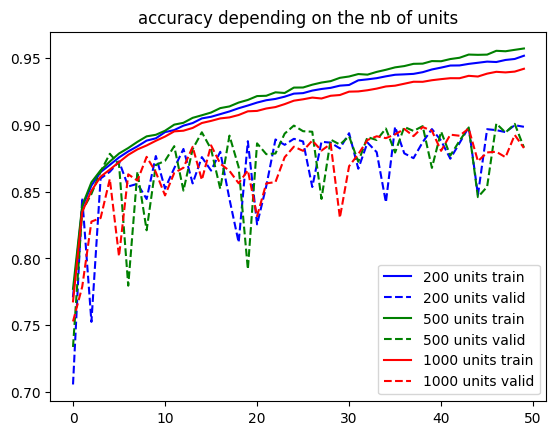

In [ ]:
plt.figure(1)
co= ['b', 'g', 'r', 'p']
for i in range(3):
  plt.plot(range(nepochs), yacc_train_[i], linestyle = '-',c=co[i])
  plt.plot(range(nepochs), yacc_valid_[i], linestyle = '--',c=co[i])

plt.title('accuracy depending on the nb of units')
plt.legend(legend)
plt.show

*On peut observer qu'un nombre de neurones d'envirion 500 est un bon choix pour avoir la meilleure précision et le coût le plus bas. Toutefois, au delà de 200 neurones, l'amélioration n'est pas très notable. Les résultats restent similaires*

In [ ]:
# 5. 2 hidden layer with 50 units
model_5 = mlp([28*28, 50, 50, 10])
cost_train_5, cost_valid_5, acc_train_5, acc_valid_5 = train_eval(model_5, lr, nepochs, nbatch, training_data, validation_data)

In [ ]:
# 6. 3 hidden layer with 50 units
model_6 = mlp([28*28, 50, 50, 50, 10])
cost_train_6, cost_valid_6, acc_train_6, acc_valid_6 = train_eval(model_6, lr, nepochs, nbatch, training_data, validation_data)

### *COST*

<function matplotlib.pyplot.show(close=None, block=None)>

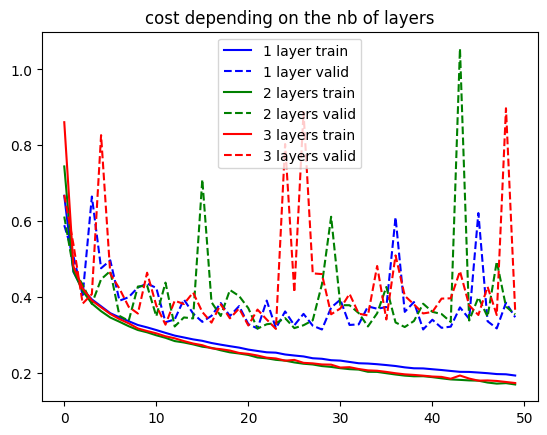

In [ ]:
legend = ["1 layer train", "1 layer valid", "2 layers train", "2 layers valid", "3 layers train", "3 layers valid"]
ycost_train__ = [cost_train_4, cost_train_5, cost_train_6]
ycost_valid__ = [cost_valid_4, cost_valid_5, cost_valid_6]
yacc_train__ = [acc_train_4, acc_train_5, acc_train_6]
yacc_valid__ = [acc_valid_4, acc_valid_5, acc_valid_6]

plt.figure(1)
co= ['b', 'g', 'r']
for i in range(3):
  plt.plot(range(nepochs), ycost_train__[i], linestyle = '-',c=co[i])
  plt.plot(range(nepochs), ycost_valid__[i], linestyle = '--',c=co[i])

plt.title('cost depending on the nb of layers')
plt.legend(legend)
plt.show

### *ACCURACY*

<function matplotlib.pyplot.show(close=None, block=None)>

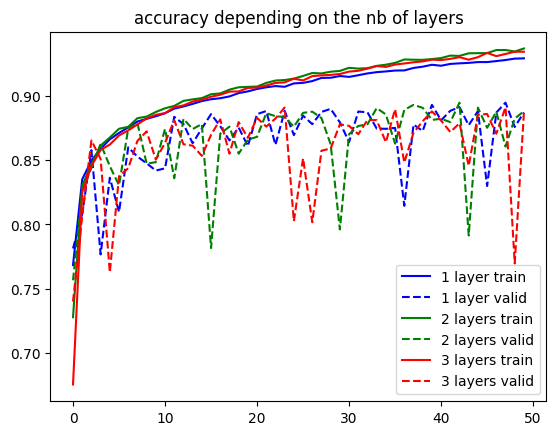

In [ ]:
plt.figure(1)
co= ['b', 'g', 'r']
for i in range(3):
  plt.plot(range(nepochs), yacc_train__[i], linestyle = '-',c=co[i])
  plt.plot(range(nepochs), yacc_valid__[i], linestyle = '--',c=co[i])

plt.title('accuracy depending on the nb of layers')
plt.legend(legend)
plt.show

*L'ajout de couche ne change pas drastiquement les valeurs de précision et de coût.*

*Nous pouvons donc déduire de ces observations qu'accroitre le nombre de neurones ou de couches ne conduit pas à des améliorations notables.*

*Nous devons donc appliquer de la régularisation sur les couches et neurones existants plutôt que d'en ajouter.*

### Add Regularisation

Finally, add regularisation - dropout or L1/L2-regularisation.

To this end, you need to implement new functionality to instantiate the model.

Start with one of the overfitting cases of Exercise 3 and try to improve the validation performance by adding regularisation. You can use either dropout or L1/L2-regularisation.


In [ ]:
# define a method that provides an instance of an MLP incl regularisation which uses as a list of units per layer as input

def mlp_dropout(units = [28*28, 200, 10], p_in = 0.2, p_hidden=0.5):
    """
    Creates an instance of an MLP with layers as specified in the 'units'-list (list of integers) and dropout
    regularisation. Dropout rate for all layers the same except for the first (p_in). For the output layer
    no dropout applied.
    """
    seq = [torch.nn.Flatten()]
    seq.append(torch.nn.Dropout(p_in))
    for i in range(len(units)-1):
        seq.append(torch.nn.Linear(units[i], units[i+1]))
        if i < len(units)-2:
            seq.append(torch.nn.ReLU())
            seq.append(torch.nn.Dropout(p_hidden))
    return torch.nn.Sequential(*seq)


In [ ]:
model = mlp_dropout([28*28,200,10])

from torchsummary import summary
summary(model, (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
           Dropout-2                  [-1, 784]               0
            Linear-3                  [-1, 200]         157,000
              ReLU-4                  [-1, 200]               0
           Dropout-5                  [-1, 200]               0
            Linear-6                   [-1, 10]           2,010
Total params: 159,010
Trainable params: 159,010
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 0.61
Estimated Total Size (MB): 0.63
----------------------------------------------------------------


#### Playing with different complexities and regularisation

Now play with different complexities and regularisation.
Start with one of the overfitting cases identified in the previous exercise.
By adding regularisation, you should be able to make it non-overfitting, i.e. generalising better.
Note that for a given complexity, adding regularisation reduces the model capacity. This may need to be compensated by increasing the complexity of the model.

Use again cost and accuracy for train and validation set to evaluate the results.


In [ ]:
lr = 0.1
nepochs = 100
nbatch = 32

In [ ]:
# 1. Modèle avec un 1 batch, 32 samples, 1 couche, 50 neurones
nbatches = 1
model_reg_1 = mlp_dropout([28*28, 50, 10])
trainsize = nbatches*nbatch
trainset = torch.utils.data.random_split(training_data, [trainsize, 50000-trainsize])[0]
cost_train_reg_1, cost_valid_reg_1, acc_train_reg_1, acc_valid_reg_1 = train_eval(model_reg_1, lr, nepochs, nbatch, trainset, validation_data)

In [ ]:
# 2. Modèle avec un 10 batch, 32 samples, 1 couche, 50 neurones
nbatches = 10
model_reg_2 = mlp_dropout([28*28, 50, 10])
trainsize = nbatches*nbatch
trainset = torch.utils.data.random_split(training_data, [trainsize, 50000-trainsize])[0]
cost_train_reg_2, cost_valid_reg_2, acc_train_reg_2, acc_valid_reg_2 = train_eval(model_reg_2, lr, nepochs, nbatch, trainset, validation_data)

In [ ]:
# 3. Modèle avec 1 batch, 32 samples, 2 couches, 50 neurones
model_reg_3 = mlp_dropout([28*28, 50, 50, 10])
cost_train_reg_3, cost_valid_reg_3, acc_train_reg_3, acc_valid_reg_3 = train_eval(model_reg_3, lr, nepochs, nbatch, training_data, validation_data)

### *COST*

<function matplotlib.pyplot.show(close=None, block=None)>

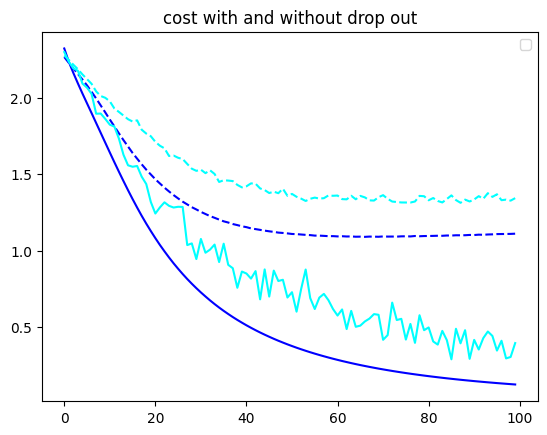

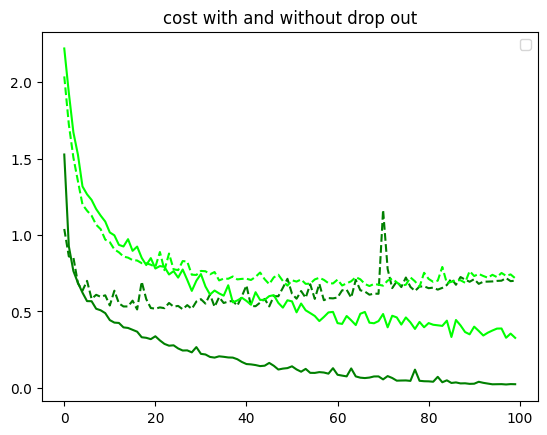

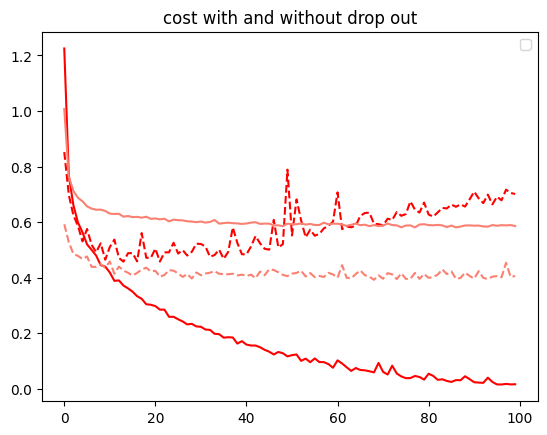

In [ ]:
legend = ["m1 train", "m1 valid", "m1 train reg", "m1 valid reg", "m2 train", "m2 valid", "m2 train reg", "m2 valid reg", "m3 train", "m3 valid", "m3 train reg", "m3 valid reg"]
ycost_train_reg = [cost_train, cost_train_reg_1, cost_train2, cost_train_reg_2, cost_train3, cost_train_reg_3]
ycost_valid_reg = [cost_valid, cost_valid_reg_1, cost_valid2, cost_valid_reg_2, cost_valid3, cost_valid_reg_3]
yacc_train_reg = [acc_train, acc_train_reg_1, acc_train2, acc_train_reg_2, acc_train3, acc_train_reg_3]
yacc_valid_reg = [acc_valid, acc_valid_reg_1, acc_valid2, acc_valid_reg_2, acc_valid3, acc_valid_reg_3]

co= ['b', 'cyan', 'g', 'lime', 'r', 'salmon']
for i in range(6):
    if i % 2 == 0:
        plt.figure(i)
        plt.title("cost with and without drop out")
        plt.legend(legend)
    plt.plot(range(nepochs), ycost_train_reg[i], linestyle = '-',c=co[i])
    plt.plot(range(nepochs), ycost_valid_reg[i], linestyle = '--',c=co[i])


plt.show

### *ACCURACY*

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 640x480 with 0 Axes>

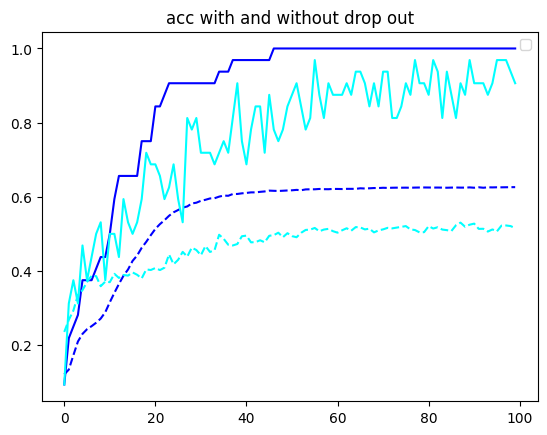

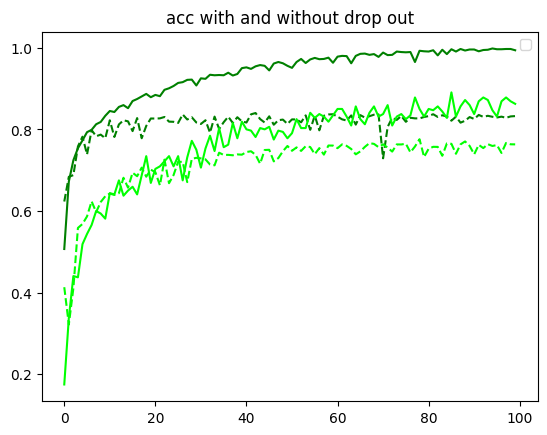

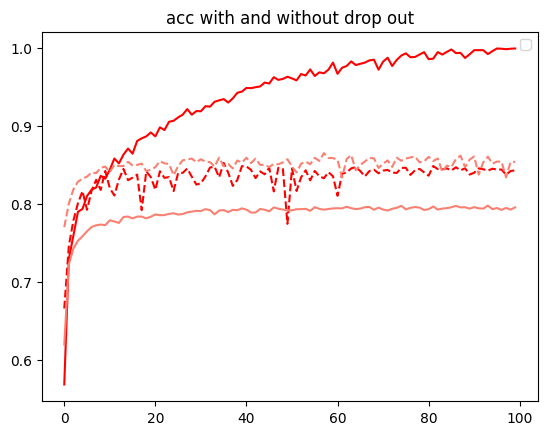

In [ ]:
plt.figure(1)
co= ['b', 'cyan', 'g', 'lime', 'r', 'salmon']
for i in range(6):
    if i % 2 == 0:
        plt.figure(i)
        plt.title("acc with and without drop out")
        plt.legend(legend)
    plt.plot(range(nepochs), yacc_train_reg[i], linestyle = '-',c=co[i])
    plt.plot(range(nepochs), yacc_valid_reg[i], linestyle = '--',c=co[i])

plt.show

*On peut voir les résultats sont moins soumis à l'overfitting suite à l'application de dropout. En effet, les courbes claires (modèles avec dropout) ont une précision plus faible que les courbes foncé (modèles sans dropout). Sur le 3e modèle (rouge), on peut voir que l'overfitting est moindre car l'écart entre la précision du train (trait plein) et du validation (trait pointillé) est plus petit.*


Finally, estimate the bias error and the generalisation error.

In [ ]:
# 1 - acc avec droupout
biais_error1 = 1 - acc_valid_reg_1[0]
biais_error2 = 1 - acc_valid_reg_2[0]
biais_error3 = 1 - acc_valid_reg_3[0]
print(biais_error1)
print(biais_error2)
print(biais_error3)

0.7646
0.5867
0.22999999999999998
0.5106999999999999


In [ ]:
# acc train avec dropout - acc valid avec dropout
# variance
generalisation_error1 = (acc_train_reg_1[0] - acc_valid_reg_1[0])**2
generalisation_error2 = (acc_train_reg_2[0] - acc_valid_reg_2[0])**2
generalisation_error3 = (acc_train_reg_3[0] - acc_valid_reg_3[0])**2
print(generalisation_error1)
print(generalisation_error2)
print(generalisation_error3)

0.0200647225
0.056786890000000007
0.02271651839999999
0.05817744000000001


*Aux vues des résultats de biais et de variance, un léger underfitting apparait. Nous avons un biais plus élévé que la variance. Le dropout a été efficace pour rendre le modèle plus résilient et plus efficace à généraliser.*